# Bond valuation and accrued interest

Trace a bond price to coupons, principal, day counts and discounting.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A bond price becomes inspectable when every remaining payment has a date, amount and discount factor. The dirty price is the present value of those payments; the clean price removes accrued interest under the contract's accrual convention.

$$P_{dirty}=\sum_i CF_iD(0,t_i),\qquad P_{clean}=P_{dirty}-AI.$$

The case is a synthetic USD 100-face bond paying 4% annually in semiannual installments, issued in March 2026 and maturing in September 2033. The primary day count is Actual/Actual ISMA. The notebook reconstructs the dated cash flows independently and reconciles their discounted sum with QuantLib at 15 September 2026. A second valuation one month later uses a newly anchored flat 3.5% curve solely to expose nonzero accrued interest and verify the clean/dirty identity.

The second date is a separate convention exercise, not a holding-period P&L or a forecast of curve evolution. On each date, past/reference-date payments are excluded consistently. Zero settlement days keeps the independent PV and the engine on the same date; production settlement rules require corresponding treatment.

There is no credit, liquidity, tax or embedded-option spread. The price is therefore conditional on the supplied discount curve and synthetic contract, not a valuation of a quoted Treasury CUSIP or corporate bond. The risk chapter builds on the same cash-flow view to distinguish a yield derivative from a rebuilt-curve quote sensitivity.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from research.pricing import bond
with valuation_date():
    d,_,_=curves()
    instrument,flows=bond(d)
    primary={'date':DATE.ISO(),'clean':instrument.cleanPrice(),'accrued':instrument.accruedAmount(),'dirty':instrument.dirtyPrice(),'PV':instrument.NPV()}
    assert abs(flows.pv.sum()-instrument.NPV()) < 1e-8
later=ql.Date(15,10,2026)
with valuation_date(later):
    shifted=ql.FlatForward(later,.035,ql.Actual365Fixed())
    instrument,_=bond(shifted)
    followup={'date':later.ISO(),'clean':instrument.cleanPrice(),'accrued':instrument.accruedAmount(),'dirty':instrument.dirtyPrice(),'PV':instrument.NPV()}
    independent=sum(cf.amount()*shifted.discount(cf.date()) for cf in instrument.cashflows() if cf.date()>later)
    assert abs(independent-instrument.NPV()) < 1e-8
prices=pd.DataFrame([primary,followup])
assert np.allclose(prices.clean+prices.accrued,prices.dirty,atol=1e-10)
assert followup['accrued'] > 0
display(prices.round(6));display(flows.round(6))

,date,clean,accrued,dirty,PV
0,2026-09-15,103.195569,0.000000,103.195569,103.195569
1,2026-10-15,102.835757,0.331492,103.167249,103.167249


,instrument,date,accrual,amount,discount,pv
0,bond,2027-03-15,0.5,2.0,0.981428,1.962856
1,bond,2027-09-15,0.5,2.0,0.962902,1.925803
2,bond,2028-03-15,0.5,2.0,0.945858,1.891717
3,bond,2028-09-15,0.5,2.0,0.928934,1.857869
4,bond,2029-03-15,0.5,2.0,0.913498,1.826996
5,bond,2029-09-17,0.5,2.0,0.897902,1.795804
6,bond,2030-03-15,0.5,2.0,0.883150,1.766300
7,bond,2030-09-16,0.5,2.0,0.868158,1.736316
8,bond,2031-03-17,0.5,2.0,0.854105,1.708209
9,bond,2031-09-15,0.5,2.0,0.840278,1.680557


## Economic relationship

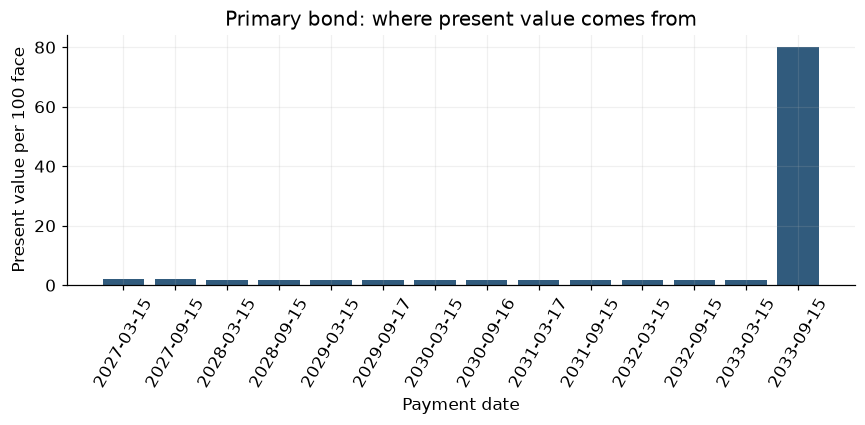

In [3]:
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(flows.date,flows.pv,color='#315b7d')
ax.set(xlabel='Payment date',ylabel='Present value per 100 face',title='Primary bond: where present value comes from')
ax.tick_params(axis='x',rotation=60);fig.tight_layout();plt.show()

## Interpretation

The cash-flow sum matches the engine. Accrued interest is zero on the primary coupon date and positive in the separate October convention example; clean and dirty prices reconcile on both dates.